# Neural ODEs in NeuroMANCER  


This tutorial demonstrates the use of [Neural Ordinary Differential Equations](https://arxiv.org/abs/1806.07366) (NODE) for system identificaiton of dynamical systems. 


## System Identification Problem Setup

<img src="./NODE_method.png" width="600">


Starting from a given initial condition  $x_{0}$, the next state of the system  $x_{k+1}$
is obtained by feeding the current state $x_{k}$ into the neural network $N$ that generates a derivative to be
integrated using an integration scheme $\int$. In system identification, the loss $\mathcal{L}$ is evaluated by comparing the  trajectory generated by the model with the training trajectory. The process can be repeated for multiple trajectories to improve the generalization of the model.


### References

[1] [Ricky T. Q. Chen, Yulia Rubanova, Jesse Bettencourt, David Duvenaud, Neural Ordinary Differential Equations, NeurIPS 2018](https://arxiv.org/abs/1806.07366)  
[2] http://implicit-layers-tutorial.org/neural_odes/  
[3] https://github.com/Zymrael/awesome-neural-ode  
[4] https://rkevingibson.github.io/blog/neural-networks-as-ordinary-differential-equations/  
[5] [Christian Legaard, Thomas Schranz, Gerald Schweiger, Ján Drgoňa, Basak Falay, Cláudio Gomes, Alexandros Iosifidis, Mahdi Abkar, and Peter Larsen. 2023. Constructing Neural Network Based Models for Simulating Dynamical Systems. ACM Comput. Surv. 55, 11, Article 236 (November 2023), 34 pages.](https://dl.acm.org/doi/10.1145/3567591)



## NeuroMANCER and Dependencies

### Install (Colab only)
Skip this step when running locally.

In [21]:
!pip install neuromancer

*Note: When running on Colab, one might encounter a pip dependency error with Lida 0.0.10. This can be ignored*

In [22]:
import torch
from neuromancer.psl import plot
from neuromancer import psl
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader

from neuromancer.system import Node, System
from neuromancer.dynamics import integrators, ode
from neuromancer.trainer import Trainer
from neuromancer.problem import Problem
from neuromancer.loggers import BasicLogger
from neuromancer.dataset import DictDataset
from neuromancer.constraint import variable
from neuromancer.loss import PenaltyLoss
from neuromancer.modules import blocks

torch.manual_seed(0)

## Generate trajectories from ODE system 

Consider the [VanDerPol system](https://en.wikipedia.org/wiki/Van_der_Pol_oscillator) defined by the [ordinary differential equations](https://en.wikipedia.org/wiki/Ordinary_differential_equation): 

$$
 \frac{dx_1}{dt} = \mu (x_1 - \frac{1}{3}x_1^3 - x_2)   \\  
 \frac{dx_2}{dt} = \frac{x_1}{\mu} 
$$  

In this example we don't assume any prior knowledge on the system dynamics. We will only have access to limited measurements of the system states $x$.

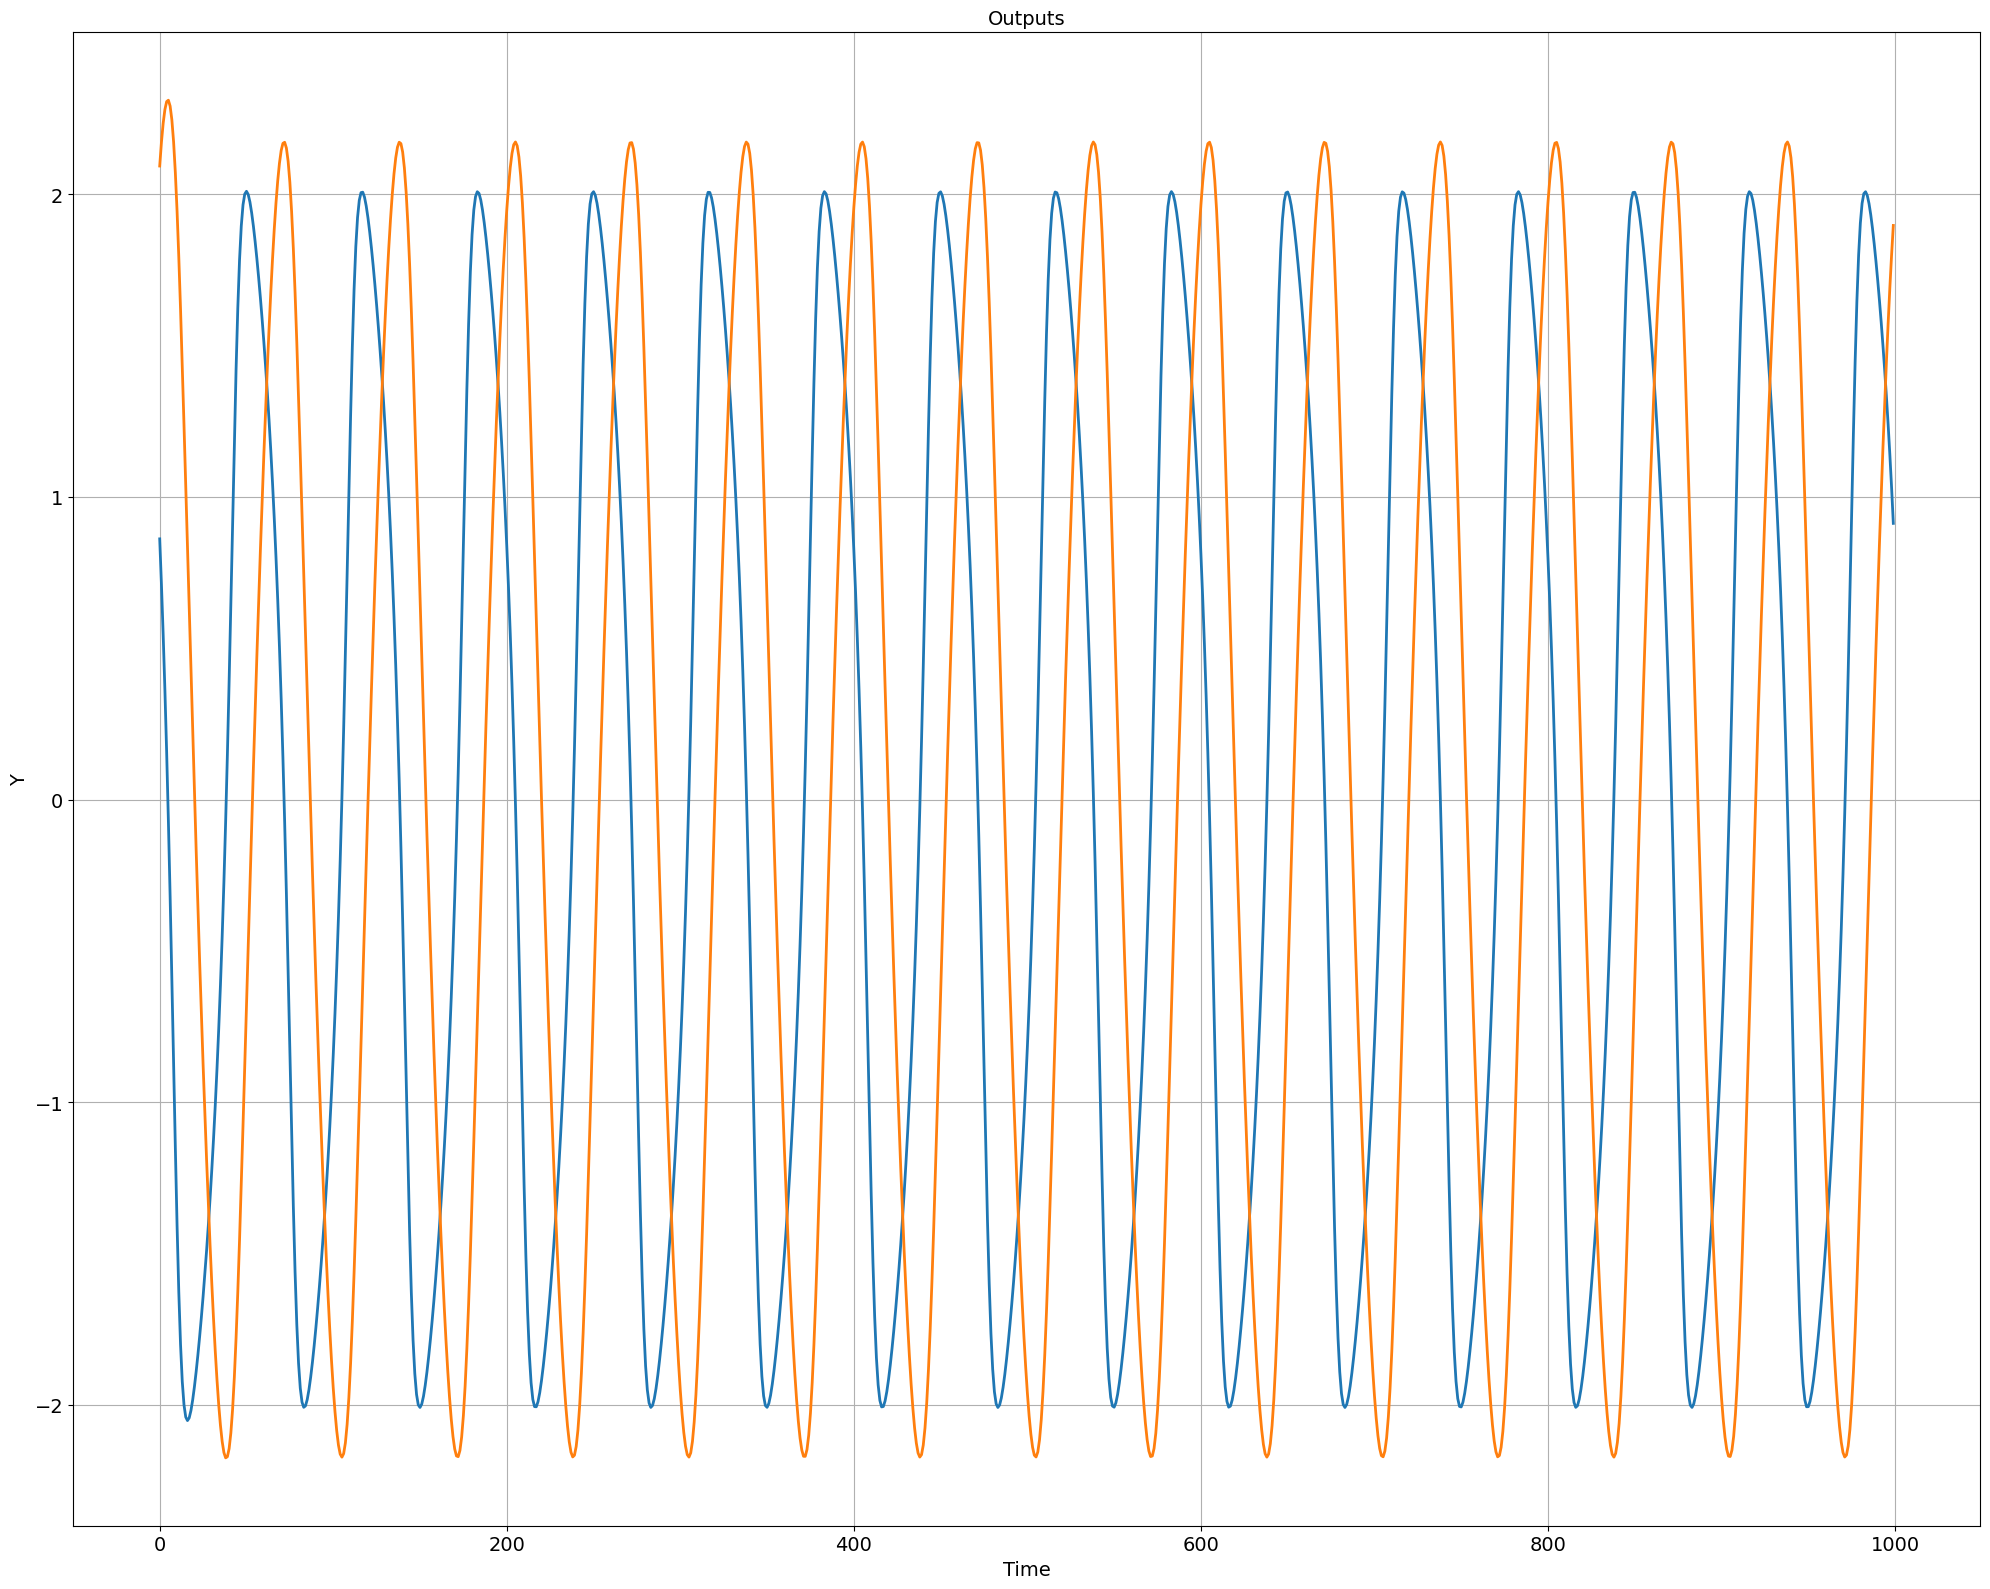

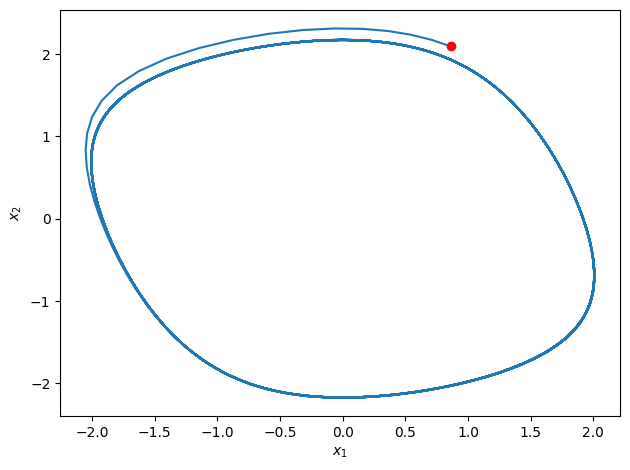

In [23]:
# %%  ground truth system
system = psl.systems['VanDerPol']
modelSystem = system()
ts = modelSystem.ts
nx = modelSystem.nx
raw = modelSystem.simulate(nsim=1000, ts=ts)
plot.pltOL(Y=raw['Y'])
plot.pltPhase(X=raw['Y'])

## Create training data of sampled trajectories

We will obtain a dataset of sampled trajectories of the system dynamics to model: 
$$\hat{X} = [\hat{x}^i_0, ..., \hat{x}^i_{N}], \, \, i \in [1, ..., m]$$
where $N$ represents the prediction horizon, $m$ represents number of measured trajectories, and $i$ represents an index of the sampled trajectory.


In [24]:
def get_data(sys, nsim, nsteps, ts, bs):
    """
    :param nsteps: (int) Number of timesteps for each batch of training data
    :param sys: (psl.system)
    :param ts: (float) step size
    :param bs: (int) batch size

    """
    train_sim, dev_sim, test_sim = [sys.simulate(nsim=nsim, ts=ts) for i in range(3)]
    nx = sys.nx
    nbatch = nsim//nsteps
    length = (nsim//nsteps) * nsteps

    trainX = train_sim['X'][:length].reshape(nbatch, nsteps, nx)
    trainX = torch.tensor(trainX, dtype=torch.float32)
    train_data = DictDataset({'X': trainX, 'xn': trainX[:, 0:1, :]}, name='train')
    train_loader = DataLoader(train_data, batch_size=bs,
                              collate_fn=train_data.collate_fn, shuffle=True)

    devX = dev_sim['X'][:length].reshape(nbatch, nsteps, nx)
    devX = torch.tensor(devX, dtype=torch.float32)
    dev_data = DictDataset({'X': devX, 'xn': devX[:, 0:1, :]}, name='dev')
    dev_loader = DataLoader(dev_data, batch_size=bs,
                            collate_fn=dev_data.collate_fn, shuffle=True)

    testX = test_sim['X'][:length].reshape(1, nsim, nx)
    testX = torch.tensor(testX, dtype=torch.float32)
    test_data = {'X': testX, 'xn': testX[:, 0:1, :]}

    return train_loader, dev_loader, test_data

In [25]:
nsim = 600   # number of simulation steps in the dataset
nsteps = 2   # number of prediction horizon steps in the loss function
bs = 100     # minibatching batch size
train_loader, dev_loader, test_data = get_data(modelSystem, nsim, nsteps, ts, bs)

## NODE system model in Neuromancer

Here we construct a continuous-time NODE model  $\dot{x} = f_{\theta}(x)$ with the unknown right hand side $f_{\theta}(x)$ represented by a multi-layer perceptron (MLP) neural network with trainable parameters $\theta$.

In [26]:
# define neural network of the NODE
fx = blocks.MLP(nx, nx, bias=True,
                 linear_map=torch.nn.Linear,
                 nonlin=torch.nn.ReLU,
                 hsizes=[60, 60, 60])

### Differentiating through the ODE Solver

Next we need to solve the continuous-time NODE model using a numerical ODE integrator, such as a [Runge–Kutta method](https://en.wikipedia.org/wiki/Runge%E2%80%93Kutta_methods).

$
x(T) = \text{ODESolve}(f_{\theta}, x(t_0), [t_0, T])
$

Training requires gradients of the loss with respect to the neural network parameters $\theta$. Since the ODE solver is part of the computational graph, we must differentiate through the integration procedure itself. Two principal approaches are commonly used:

1. **Backpropagation Through Time (BPTT)** — differentiate through the discretized solver.
2. **Adjoint Sensitivity Method (ASM)** — differentiate through the continuous-time dynamics.

---


### Backpropagation Through Time (BPTT)

In [BPTT](https://en.wikipedia.org/wiki/Backpropagation_through_time), the ODE solver is interpreted as an unrolled sequence of discrete-time updates. The integration process becomes a computational graph consisting of individual solver steps,

$
x_0 \rightarrow x_1 \rightarrow x_2 \rightarrow \cdots \rightarrow x_T.
$

The parameter gradients are then obtained by applying reverse-mode automatic differentiation through the unrolled computational graph propagating sensitivities backward through every integration step

$
\nabla_\theta \mathcal L
=
\text{Backprop}
\left(
\text{ODESolve}
(f_\theta,\,
x(t_0),\,
[t_0,T])
\right).
$

  BPTT computes exact gradients of the discretized ODE solver, at the cost of storing the complete forward trajectory in memory.
Conceptually, this is identical to training recurrent neural networks using BPTT.

Schematics illustrating the BPTT method:

<img src="./BPTT.png" width="500">

**Pros**
- Exact gradients for the discretized numerical solver.
- Typically more numerically stable.
- Native support in modern automatic differentiation libraries.

**Cons**
- High memory consumption.
- Requires storing all intermediate solver states.

---

### Adjoint Sensitivity Method (ASM)

Rather than differentiating through every solver step, the adjoint sensitivity method introduces a continuous-time adjoint variable

$
a(t)=\frac{\partial \mathcal L}{\partial x(t)},
$

which evolves backward in time according to the Adjoint Dynamics differential equation

$
\boxed{
\frac{da(t)}{dt}
=
-\left(
\frac{\partial f_\theta}{\partial x}
\right)^T
a(t),
\qquad
a(T)=
\frac{\partial\mathcal L}{\partial x(T)}.
}
$

The parameter gradients are accumulated simultaneously by integrating an augmented adjoint ODE system,

$
(a(t_0),\,g(t_0))
=
\text{ODESolve}
\left(
\text{AdjointDynamics},
\;
(a(T),\,0),
\;
[T,t_0]
\right),
$

yielding the final gradient
$
\nabla_\theta\mathcal L=g(t_0).
$

The forward pass solves the state ODE from the initial time $t_0$  to the terminal time $ T$ . The backward pass then solves the augmented adjoint ODE from $T$  back to $ t_0$ , typically using the same numerical integration scheme. Consequently, gradients are obtained without explicitly differentiating through every solver step or storing the complete forward trajectory.

Schematics illustrating the adjoint method introduced in the [Neural Ordinary Differential Equations](https://arxiv.org/abs/1806.07366) paper:

<img src="./NODE_backprop.png" width="500">

**Pros**
- Memory efficient.
- Does not require storing the full forward trajectory.
- Elegant continuous-time formulation.

**Cons**
- Gradients are approximate because they depend on numerical integration of the adjoint equations.
- Error accumulation can lead to numerical instability.
- May produce gradients that differ from those of the discretized solver.

---

### Which Method Should I Use?

Although both methods use the same numerical ODE solver in the forward pass, BPTT differentiates the discretized solver itself, whereas the ASM derives a continuous-time adjoint system and then discretizes it for backward integration. Since differentiation and discretization generally do not commute, the ASM may produce gradients that differ from the exact gradients of the numerical solver, especially for adaptive or stiff integrators.

When memory permits, BPTT is often preferred because it computes the exact gradients of the discretized numerical solver and tends to be more numerically robust. Its primary drawback is memory consumption, as the complete forward trajectory must be stored for the backward pass.

In contrast, ASM significantly reduces memory usage by reconstructing gradients through a backward integration of the adjoint dynamics, making it attractive for long trajectories and large-scale Neural ODEs. However,
 [subsequent works](https://arxiv.org/abs/1902.10298) has shown that the [continuous adjoint method for NODEs](https://arxiv.org/abs/1806.07366) can suffer from numerical instability and inaccurate gradient estimates. Consequently, errors accumulated during the backward integration may lead to gradients that differ from those of the discretized forward solver.

Neuromancer provides several differentiable ODE solvers implemented in [`integrators.py`](https://github.com/pnnl/neuromancer/blob/master/src/neuromancer/dynamics/integrators.py). For adjoint-based training, Neuromancer also provides an interface to the popular [`torchdiffeq`](https://github.com/rtqichen/torchdiffeq) implementation through the `DiffEqIntegrator` class.


In [27]:
# integrate NODE with adjoint-based solver
fxRK4 = integrators.DiffEqIntegrator(fx, h=ts, method='rk4')

Next we construct an open-loop system composed of a smbolic NODE model

In [29]:
# create symbolic system model in Neuromancer
model = Node(fxRK4, ['xn'], ['xn'], name='NODE')
dynamics_model = System([model], name='system', nsteps=nsteps)

## Define system identification loss function terms

Here we define loss function terms to fit the ODE parameters from given time-series data.

**Tracking loss:**  
$$\ell_x = Q_x||x^i_k - \hat{x}^i_k||_2^2$$ 
**Finite difference loss:**  
$$\ell_{dx} =  Q_{dx}||\Delta x^i_k - \Delta \hat{x}^i_k||_2^2$$
where $\Delta x^i_k = x^i_{k+1} - x^i_k$

In [30]:
# %% Constraints + losses:
x = variable("X")
xhat = variable('xn')[:, :-1, :]
# finite difference variables
xFD = (x[:, 1:, :] - x[:, :-1, :])
xhatFD = (xhat[:, 1:, :] - xhat[:, :-1, :])

# trajectory tracking loss
reference_loss = (xhat == x)^2
reference_loss.name = "ref_loss"

# finite difference loss
fd_loss = 2.*(xFD == xhatFD)^2
fd_loss.name = 'FD_loss'

## Construct System ID learning problem

Given the training dataset $\hat{X} = [\hat{x}^i_0, ..., \hat{x}^i_{N}]$ we want to solve the following problem:
 
$$
\begin{align}
&\underset{\theta}{\text{minimize}}     && \sum_{i=1}^m \Big(\sum_{k=1}^{N}  Q_x||x^i_k - \hat{x}^i_k||_2^2  +  \sum_{k=1}^{N-1}  Q_{dx}||\Delta x^i_k - \Delta \hat{x}^i_k||_2^2  \Big) \\
&\text{subject to}    && x^i_{k+1} =  \text{ODESolve}(f_{\theta}(x^i_k)) \\
\end{align}
$$  

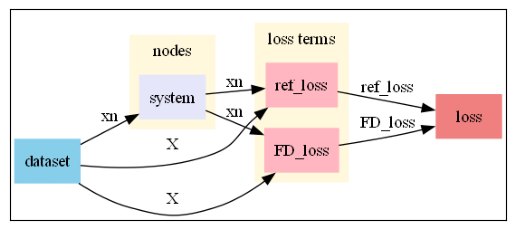

In [31]:
# aggregate list of objective terms and constraints
objectives = [reference_loss, fd_loss]
constraints = []
# create constrained optimization loss
loss = PenaltyLoss(objectives, constraints)
# construct constrained optimization problem
problem = Problem([dynamics_model], loss)
# visualize the computational graph
problem.show()

## Solve the System Identification problem

We fit the unknown NODE parameters $\theta$ using stochastic gradient descent.

In [32]:
optimizer = torch.optim.Adam(problem.parameters(), lr=0.001)
logger = BasicLogger(args=None, savedir='test', verbosity=1,
                     stdout=['dev_loss', 'train_loss'])
# define neuromancer trainer
trainer = Trainer(
    problem,
    train_loader,
    dev_loader,
    test_data,
    optimizer,
    patience=50,
    warmup=100,
    epochs=500,
    eval_metric="dev_loss",
    train_metric="train_loss",
    dev_metric="dev_loss",
    test_metric="dev_loss",
    logger=logger,
)

None
Number of parameters: 7622


In [33]:
# %% train
best_model = trainer.train()
problem.load_state_dict(best_model)

epoch: 0	train_loss: 0.04616	dev_loss: 0.04439	eltime:  2.60365
epoch: 1	train_loss: 0.04229	dev_loss: 0.04218	eltime:  2.66583
epoch: 2	train_loss: 0.04167	dev_loss: 0.04180	eltime:  2.74521
epoch: 3	train_loss: 0.03413	dev_loss: 0.03351	eltime:  2.83683
epoch: 4	train_loss: 0.03059	dev_loss: 0.02892	eltime:  2.93703
epoch: 5	train_loss: 0.02564	dev_loss: 0.02503	eltime:  3.02481
epoch: 6	train_loss: 0.02355	dev_loss: 0.02029	eltime:  3.11443
epoch: 7	train_loss: 0.01770	dev_loss: 0.01689	eltime:  3.19506
epoch: 8	train_loss: 0.01419	dev_loss: 0.01275	eltime:  3.26199
epoch: 9	train_loss: 0.00927	dev_loss: 0.00872	eltime:  3.34505
epoch: 10	train_loss: 0.00631	dev_loss: 0.00595	eltime:  3.41659
epoch: 11	train_loss: 0.00430	dev_loss: 0.00368	eltime:  3.48408
epoch: 12	train_loss: 0.00309	dev_loss: 0.00285	eltime:  3.56215
epoch: 13	train_loss: 0.00317	dev_loss: 0.00305	eltime:  3.61957
epoch: 14	train_loss: 0.00260	dev_loss: 0.00232	eltime:  3.70289
epoch: 15	train_loss: 0.00224	dev_l

<All keys matched successfully>

## Parameter estimation results

In [34]:
# update the rollout length based on the test data
dynamics_model.nsteps = test_data['X'].shape[1]

In [35]:
# Test set results
test_outputs = dynamics_model(test_data)

pred_traj = test_outputs['xn'][:, :-1, :]
true_traj = test_data['X']
pred_traj = pred_traj.detach().numpy().reshape(-1, nx)
true_traj = true_traj.detach().numpy().reshape(-1, nx)
pred_traj, true_traj = pred_traj.transpose(1, 0), true_traj.transpose(1, 0)

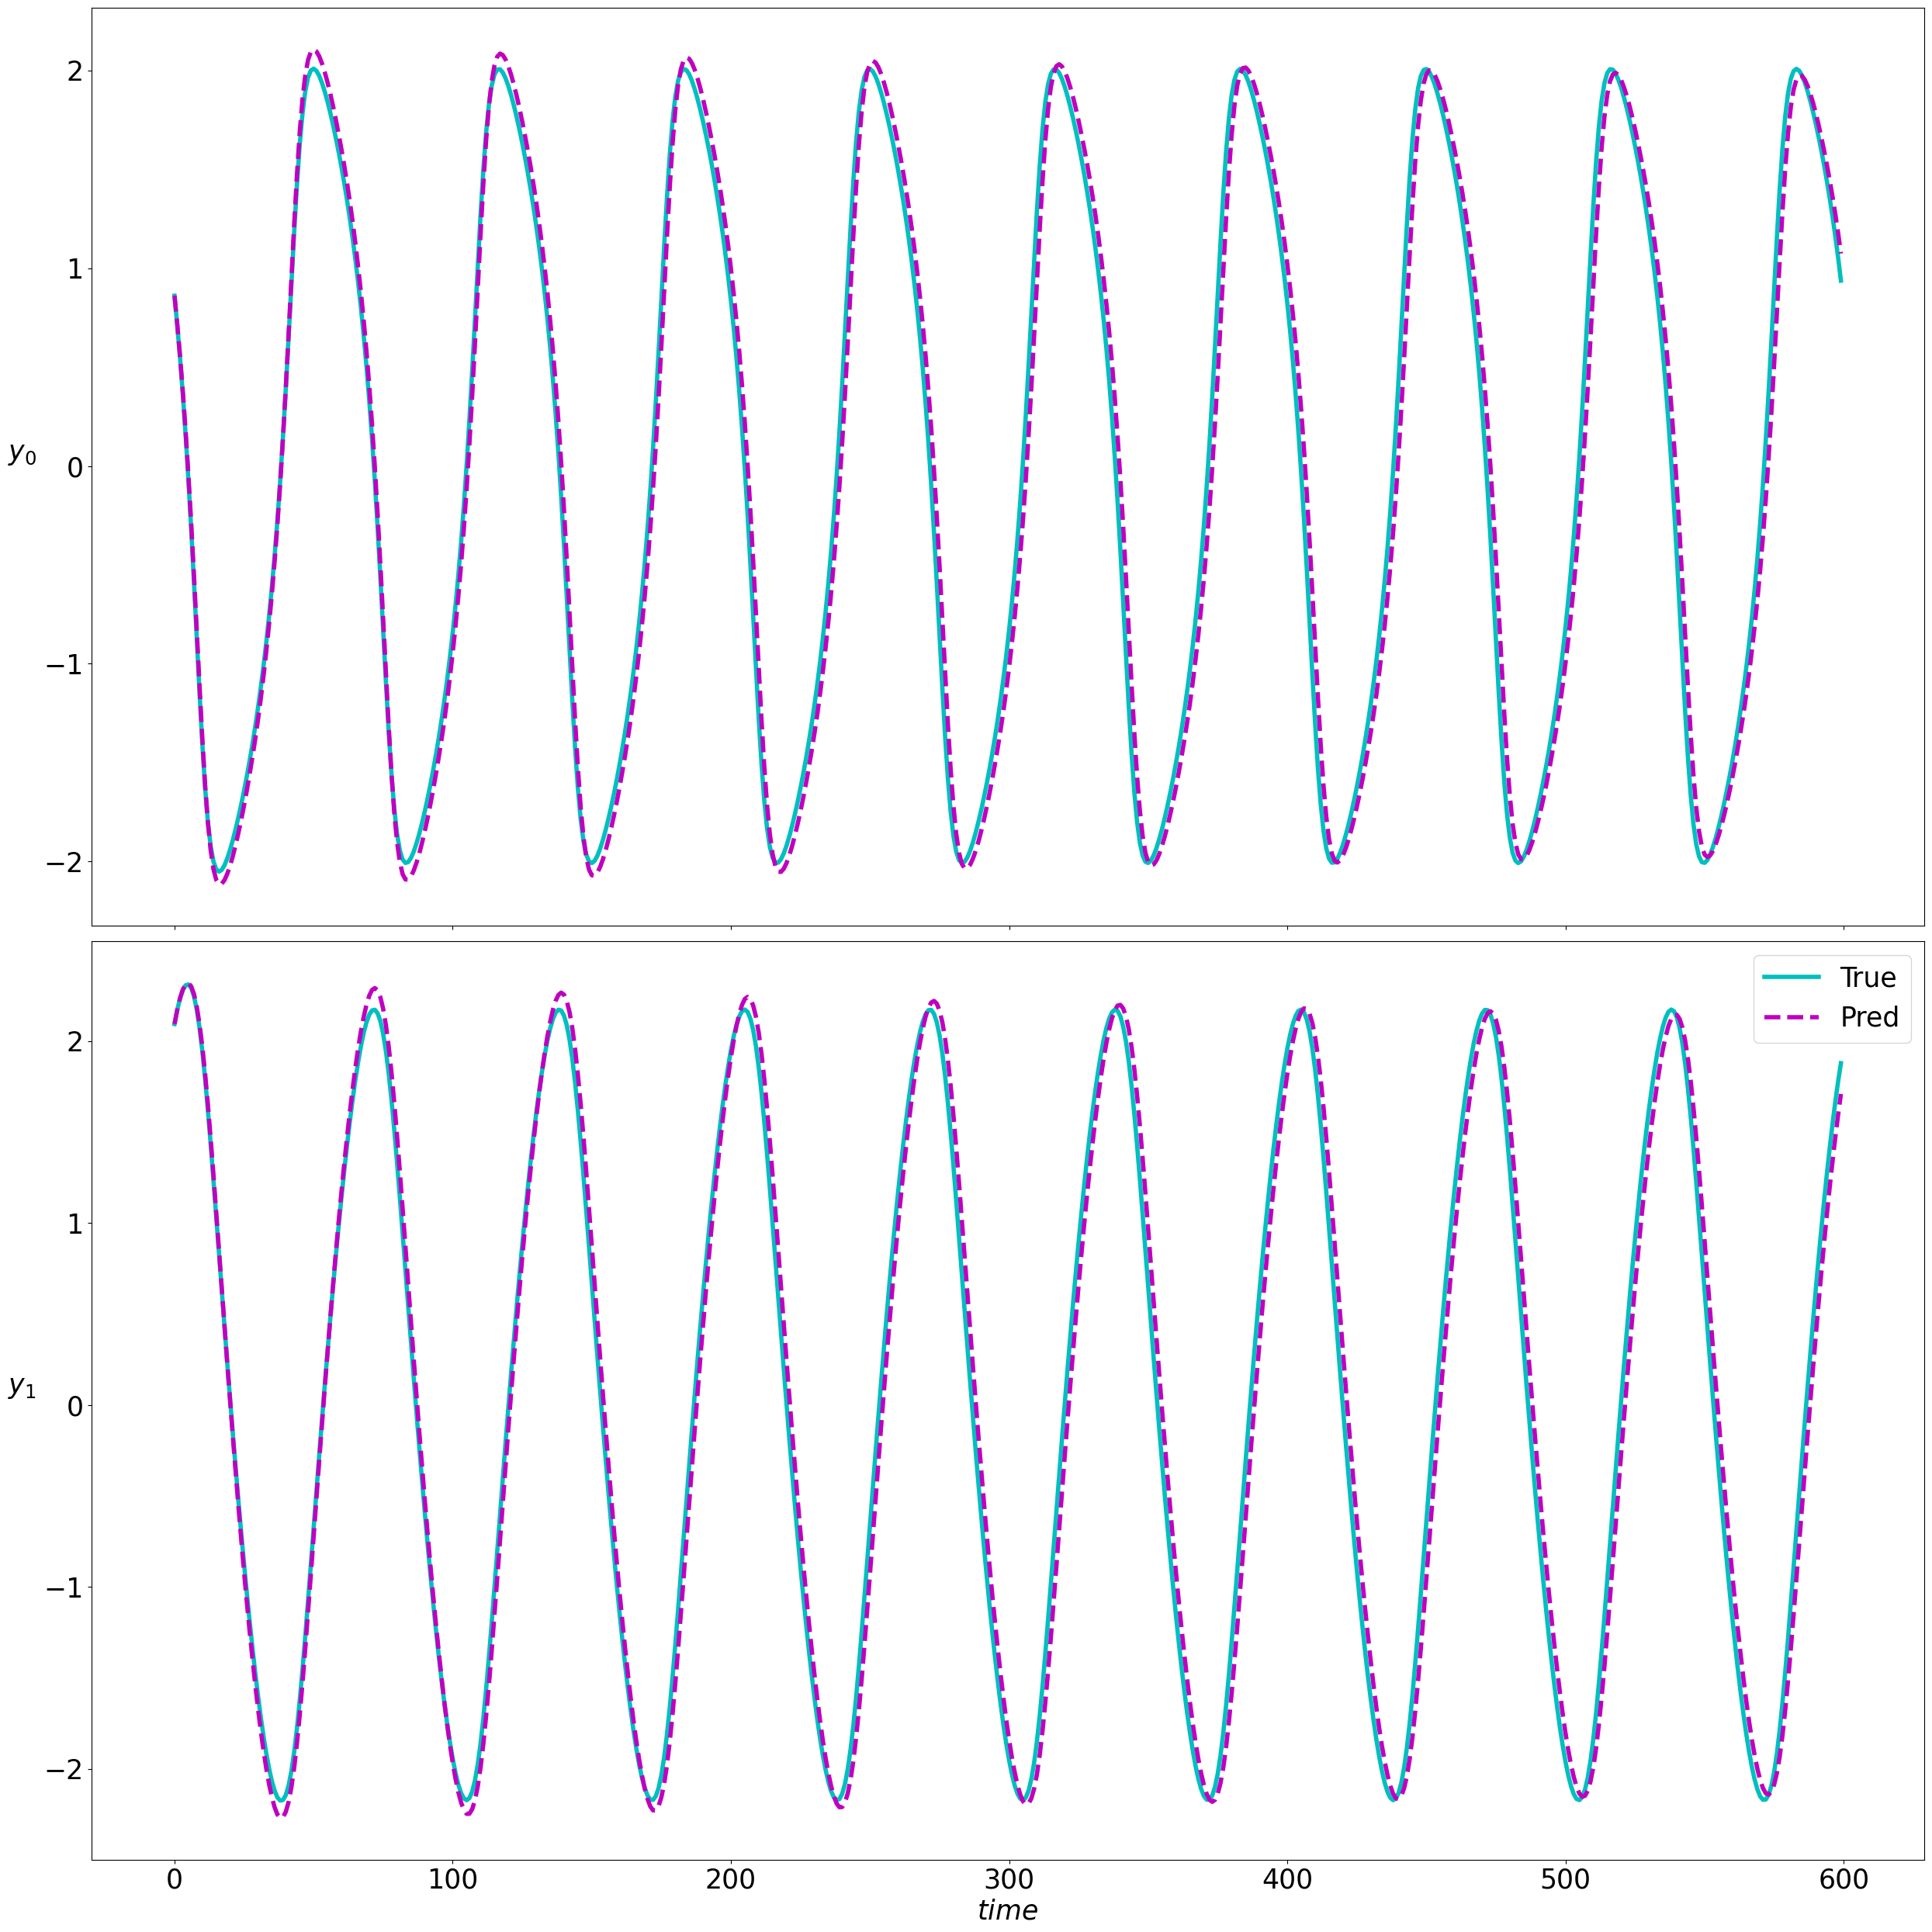

In [36]:
# plot rollout
figsize = 25
fig, ax = plt.subplots(nx, figsize=(figsize, figsize))
labels = [f'$y_{k}$' for k in range(len(true_traj))]
for row, (t1, t2, label) in enumerate(zip(true_traj, pred_traj, labels)):
    if nx > 1:
        axe = ax[row]
    else:
        axe = ax
    axe.set_ylabel(label, rotation=0, labelpad=20, fontsize=figsize)
    axe.plot(t1, 'c', linewidth=4.0, label='True')
    axe.plot(t2, 'm--', linewidth=4.0, label='Pred')
    axe.tick_params(labelbottom=False, labelsize=figsize)
axe.tick_params(labelbottom=True, labelsize=figsize)
axe.legend(fontsize=figsize)
axe.set_xlabel('$time$', fontsize=figsize)
plt.tight_layout()